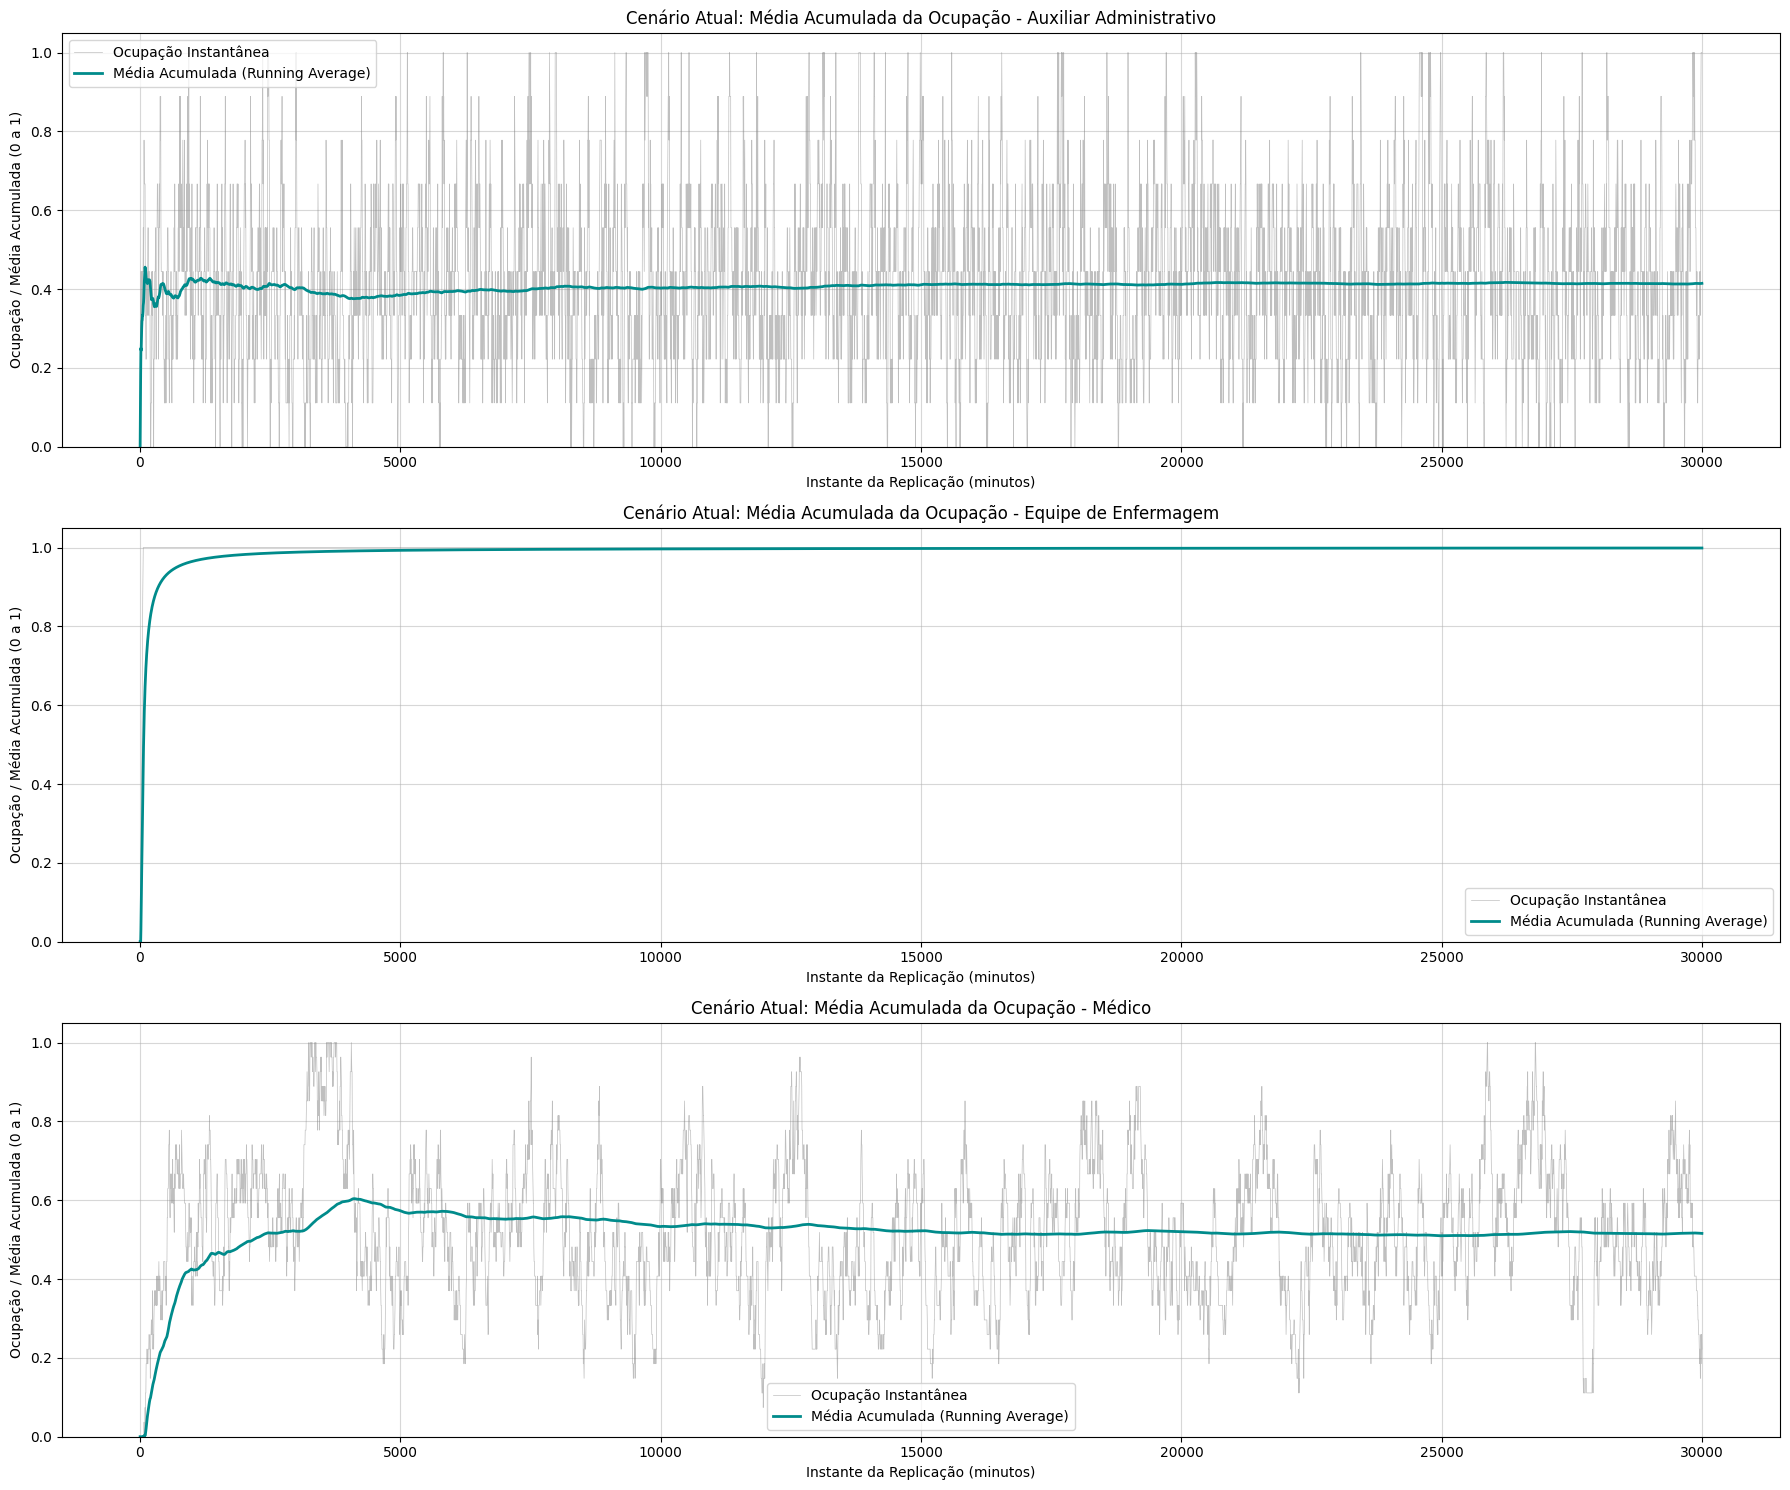

In [ ]:
import random
import simpy
import pandas as pd
import sys
import matplotlib.pyplot as plt
import os

# =========================================
# PARÂMETROS DE SIMULAÇÃO
# =========================================
num_replicacoes = 1 # Número de replicações a serem executadas
tempo_warmup = 15000  # TEMPO de warm-up em minutos (altere conforme necessidade)
tempo_de_rodada = 43200 + tempo_warmup # 43200 = 30 dias
num_replicacoes_snapshots_exportar = 5  # Quantas replicações exportar no CSV de snapshots
rodada_para_dev = False

# Porcentagens de decisão
x = 0.7  # Porcentagem dos exames que são urgentes
y = 0.005  # Porcentagem de pacientes que precisam ser reagendados

# Outros parâmetros
taxa_de_chegada_exames = 0.295
limite_preparacao_exame = 3
# Definição de prioridades para as atividades
PRIORIDADES_ATIVIDADES = {
    "01 - Organizar pedidos": 1,
    "02 - Avaliar prioridade": 2,
    "03 - Agendar exame": 0,
    "04 - Informar pré-requisitos": 2,
    "05 - Preparar paciente": 3,
    "06 - Transportar paciente": 4,
    "08 - Avaliar se exame pode ser feito no hospital": 5,
    "10 - Realizar exame no hospital": 0,  
    "11 - Atualizar MV": 5,
    "12 - Retorno do paciente ao PS": 1,
    "13 - Analisar exame urgente": 0,  
    "14 - Analisar exame não urgente": 2
}

# Mapeamento de recursos para nomes legíveis
NOMES_RECURSOS = {
    'auxiliar_adm': 'Auxiliar Administrativo',
    'medico': 'Médico',
    'equipe_enfermagem': 'Equipe de Enfermagem'
}

# Lista de todas as atividades que consomem recursos
# Usado para processamento do Tempo Médio em Fila por atividade
ATIVIDADES_COM_RECURSO = [
    "01 - Organizar pedidos", "02 - Avaliar prioridade", "03 - Agendar exame", 
    "04 - Informar pré-requisitos", "05 - Preparar paciente", "06 - Transportar paciente",
    "07 - Avaliação de realização de exame", "10 - Realizar exame no hospital", 
    "12 - Retorno do paciente ao PS", "13 - Analisar exame urgente", 
    "14 - Analisar exame não urgente"
]

# DataFrames para armazenar resultados de todas as replicações
df_estatisticas_todas_replicacoes = pd.DataFrame()
df_exames_todas_replicacoes = pd.DataFrame()
df_snapshots_todas_replicacoes = pd.DataFrame()
df_utilizacao_recursos_todas_replicacoes = pd.DataFrame()  # DataFrame para utilização de recursos
df_metricas_atividades_todas_replicacoes = pd.DataFrame() # DF para métricas por atividade
# Novo: DataFrame para snapshots de ocupação dos recursos
df_ocupacao_recursos_todas_replicacoes = pd.DataFrame() 


# Para exportar relatórios em txt
class Tee:
    def __init__(self, *files):
        self.files = files
    
    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()
    
    def flush(self):
        for f in self.files:
            f.flush()

# Uso do arquivo .txt como relatório:
arquivo_log = open('log_simulacao.txt', 'w', encoding='utf-8')
#arquivo_log = open(os.devnull, 'w', encoding='utf-8')
sys.stdout = Tee(sys.__stdout__, arquivo_log)

def distribuicoes(tipo):
    return {
        'dist_organizar_pedido': random.triangular(1, 1.5, 1),
        'dist_avaliar_prioridade': random.triangular(1, 1.5, 1),
        'dist_agendar_exame': random.triangular(30, 40, 30),
        'dist_informar_pre_requisito': random.triangular(5, 30, 20),
        'dist_preparar_paciente': random.triangular(5, 30, 20),
        'dist_transportar_paciente': random.triangular(5, 30, 20),
        'dist_avaliacao_de_realizacao_de_exame': random.triangular(5, 30, 20),
        #'dist_avaliacao_exame_pode_ser_no_hospital': random.triangular(5, 30, 20),
        'dist_realizacao_do_exame_no_hospital': random.gammavariate(1.702, 1.523),
        'dist_retorno_paciente': random.triangular(5, 30, 20),
        'dist_atualizar_mv': random.triangular(1, 5, 3),
        'dist_analisar_exame_urgente': random.triangular(10, 120, 60),
        'dist_analisar_exame_nao_urgente': random.triangular(10, 720, 360)
    }.get(tipo, 0.0)

def inicializar_metricas_exame(exame, metricas_exames, instante_chegada):
    """Inicializa o dicionário de métricas para um exame"""
    if exame not in metricas_exames:
        metricas_exames[exame] = {
            'exame': exame,
            'instante_chegada': instante_chegada,  # Armazena o instante de chegada
            'atividades_tempo_fila': {},
            'atividades_tempo_processamento': {}
        }

def registrar_snapshot_sistema(env, snapshots_sistema, num_exames_em_fila, 
                               num_exames_em_processamento, num_exames_no_sistema):
    """Registra o estado do sistema no momento atual"""
    snapshots_sistema.append({
        'tempo': env.now,
        'num_em_fila': num_exames_em_fila,
        'num_em_processamento': num_exames_em_processamento,
        'num_no_sistema': num_exames_no_sistema
    })

# NOVO: Função para monitorar a ocupação dos recursos
def monitorar_ocupacao_recursos(env, recursos, snapshots_ocupacao):
    """Monitora a ocupação de cada recurso em intervalos regulares"""
    # NOVO: Intervalo de monitoramento (pode ser ajustado se necessário)
    intervalo_monitoramento = 5 
    while True:
        # Registra a ocupação (número de pessoas ocupadas / capacidade total)
        for chave, recurso in recursos.items():
            # A ocupação é dada por: recurso.count / recurso.capacity
            ocupacao_inst = recurso.count / recurso.capacity
            snapshots_ocupacao.append({
                'Recurso': NOMES_RECURSOS.get(chave, chave),
                'Tempo': env.now,
                'Ocupacao_Instantanea': ocupacao_inst
            })
        yield env.timeout(intervalo_monitoramento)

def registrar_metrica(exame, nome_atividade, tempo_fila, tempo_processamento, metricas_exames):
    """Registra tempo de fila e processamento de uma atividade"""
    if nome_atividade not in metricas_exames[exame]['atividades_tempo_fila']:
        metricas_exames[exame]['atividades_tempo_fila'][nome_atividade] = 0
        metricas_exames[exame]['atividades_tempo_processamento'][nome_atividade] = 0
    
    metricas_exames[exame]['atividades_tempo_fila'][nome_atividade] += tempo_fila
    metricas_exames[exame]['atividades_tempo_processamento'][nome_atividade] += tempo_processamento

def obter_nome_recurso(recurso_chave):
    """Retorna o nome legível do recurso"""
    return NOMES_RECURSOS.get(recurso_chave, recurso_chave)

def registrar_utilizacao_recurso(recurso_chave, tempo_inicio, tempo_fim, utilizacao_recursos, capacidade=1):
    """Registra o tempo de utilização de um recurso"""
    if recurso_chave not in utilizacao_recursos:
        utilizacao_recursos[recurso_chave] = 0
    
    # [CHG] Garante que apenas o tempo de utilização APÓS o tempo_warmup seja registrado.
    # O tempo de início da utilização real (para o cálculo) é o maior entre tempo_inicio e tempo_warmup.
    tempo_inicio_efetivo = max(tempo_inicio, tempo_warmup) # [CHG] 

    tempo_utilizado = max(0, tempo_fim - tempo_inicio_efetivo) # [CHG] Calcula o tempo utilizado subtraindo o tempo de inicio efetivo

    utilizacao_recursos[recurso_chave] += tempo_utilizado / capacidade # [CHG]

# Funções modificadas para usar prioridade
def AtividadeCom1RecursoExame(env, exame, nome_da_atividade, recurso_chave, recurso, tempo_atividade, 
                              num_replicacao, contadores, metricas_exames, snapshots_sistema, utilizacao_recursos):
    nome_recurso = obter_nome_recurso(recurso_chave)
    num_fila_especifica = len(recurso.queue)
    print(f"[R{num_replicacao}] [{env.now:.2f}] Exame {exame} chega à atividade '{nome_da_atividade}' ({nome_recurso} - Pessoas na fila: {num_fila_especifica})")
    
    # Entra na fila
    contadores['num_exames_em_fila'] += 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    # Obtém prioridade da atividade e cria requisição com prioridade
    prioridade = PRIORIDADES_ATIVIDADES.get(nome_da_atividade, 3)  # Prioridade padrão 3
    requisicao = recurso.request(priority=prioridade)
    tempo_inicio_fila = env.now
    yield requisicao
    tempo_em_fila = env.now - tempo_inicio_fila
    
    # Sai da fila e entra em processamento
    contadores['num_exames_em_fila'] -= 1
    contadores['num_exames_em_processamento'] += 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    print(f"[R{num_replicacao}] [{env.now:.2f}] Exame {exame} inicia a atividade '{nome_da_atividade}' ({nome_recurso} - Tempo em fila = {tempo_em_fila:.2f})")
    
    tempo_inicio_processamento = env.now
    yield env.timeout(tempo_atividade)
    tempo_processamento = env.now - tempo_inicio_processamento
    
    # Registrar utilização do recurso
    registrar_utilizacao_recurso(recurso_chave, tempo_inicio_processamento, env.now, utilizacao_recursos, recurso.capacity)
    
    # Sai do processamento
    contadores['num_exames_em_processamento'] -= 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    yield recurso.release(requisicao)
    print(f"[R{num_replicacao}] [{env.now:.2f}] Exame {exame} na atividade '{nome_da_atividade}' ({nome_recurso}) finalizado (Duração: {tempo_processamento:.2f})")
    
    # Registra métricas
    registrar_metrica(exame, nome_da_atividade, tempo_em_fila, tempo_processamento, metricas_exames)

def AtividadeCom2RecursosExame(env, exame, nome_da_atividade, recurso1_chave, recurso1, recurso2_chave, recurso2, tempo_atividade, 
                              num_replicacao, contadores, metricas_exames, snapshots_sistema, utilizacao_recursos):
    nome_recurso1 = obter_nome_recurso(recurso1_chave)
    nome_recurso2 = obter_nome_recurso(recurso2_chave)
    
    num_fila_recurso1 = len(recurso1.queue)
    num_fila_recurso2 = len(recurso2.queue)
    print(f"[R{num_replicacao}] [{env.now:.2f}] Exame {exame} chega à atividade '{nome_da_atividade}' ({nome_recurso1} - Fila: {num_fila_recurso1}, {nome_recurso2} - Fila: {num_fila_recurso2})")
    
    # Entra na fila
    contadores['num_exames_em_fila'] += 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    # Obtém prioridade da atividade e cria requisições com prioridade para ambos recursos
    prioridade = PRIORIDADES_ATIVIDADES.get(nome_da_atividade, 3)  # Prioridade padrão 3
    requisicao1 = recurso1.request(priority=prioridade)
    requisicao2 = recurso2.request(priority=prioridade)
    
    tempo_inicio_fila = env.now
    
    # Espera por ambos os recursos com a mesma prioridade
    yield requisicao1 & requisicao2
    tempo_em_fila = env.now - tempo_inicio_fila
    
    # Sai da fila e entra em processamento
    contadores['num_exames_em_fila'] -= 1
    contadores['num_exames_em_processamento'] += 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    print(f"[R{num_replicacao}] [{env.now:.2f}] Exame {exame} inicia a atividade '{nome_da_atividade}' ({nome_recurso1} e {nome_recurso2} - Tempo em fila = {tempo_em_fila:.2f})")
    
    tempo_inicio_processamento = env.now
    yield env.timeout(tempo_atividade)
    tempo_processamento = env.now - tempo_inicio_processamento
    
    # Registrar utilização dos recursos
    registrar_utilizacao_recurso(recurso1_chave, tempo_inicio_processamento, env.now, utilizacao_recursos, recurso1.capacity)
    registrar_utilizacao_recurso(recurso2_chave, tempo_inicio_processamento, env.now, utilizacao_recursos, recurso2.capacity)
    
    # Sai do processamento
    contadores['num_exames_em_processamento'] -= 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    yield recurso1.release(requisicao1)
    yield recurso2.release(requisicao2)
    print(f"[R{num_replicacao}] [{env.now:.2f}] Exame {exame} na atividade '{nome_da_atividade}' ({nome_recurso1} e {nome_recurso2}) finalizado (Duração: {tempo_processamento:.2f})")
    
    # Registra métricas
    registrar_metrica(exame, nome_da_atividade, tempo_em_fila, tempo_processamento, metricas_exames)

def AtividadeCom1RecursoPaciente(env, exame, nome_da_atividade, recurso_chave, recurso, tempo_atividade,
                                 num_replicacao, contadores, metricas_exames, snapshots_sistema, utilizacao_recursos):
    nome_recurso = obter_nome_recurso(recurso_chave)
    num_fila_especifica = len(recurso.queue)
    print(f"[R{num_replicacao}] [{env.now:.2f}] Paciente do exame {exame} chega à atividade '{nome_da_atividade}' ({nome_recurso} - Pessoas na fila: {num_fila_especifica})")
    
    # Entra na fila
    contadores['num_exames_em_fila'] += 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    # Obtém prioridade da atividade e cria requisição com prioridade
    prioridade = PRIORIDADES_ATIVIDADES.get(nome_da_atividade, 3)  # Prioridade padrão 3
    requisicao = recurso.request(priority=prioridade)
    tempo_inicio_fila = env.now
    yield requisicao
    tempo_em_fila = env.now - tempo_inicio_fila
    
    # Sai da fila e entra em processamento
    contadores['num_exames_em_fila'] -= 1
    contadores['num_exames_em_processamento'] += 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    print(f"[R{num_replicacao}] [{env.now:.2f}] Paciente do exame {exame} inicia a atividade '{nome_da_atividade}' ({nome_recurso} - Tempo em fila = {tempo_em_fila:.2f})")
    
    tempo_inicio_processamento = env.now
    yield env.timeout(tempo_atividade)
    tempo_processamento = env.now - tempo_inicio_processamento
    
    # Registrar utilização do recurso
    registrar_utilizacao_recurso(recurso_chave, tempo_inicio_processamento, env.now, utilizacao_recursos, recurso.capacity)
    
    # Sai do processamento
    contadores['num_exames_em_processamento'] -= 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    yield recurso.release(requisicao)
    print(f"[R{num_replicacao}] [{env.now:.2f}] Paciente do exame {exame} na atividade '{nome_da_atividade}' ({nome_recurso}) finalizado (Duração: {tempo_processamento:.2f})")
    
    # Registra métricas
    registrar_metrica(exame, nome_da_atividade, tempo_em_fila, tempo_processamento, metricas_exames)

def AtividadeSemRecurso(env, exame, nome_da_atividade, tempo_atividade, num_replicacao,
                       contadores, metricas_exames, snapshots_sistema):
    """Para atividades que consomem tempo mas não usam recursos"""
    print(f"[R{num_replicacao}] [{env.now:.2f}] Exame {exame} chega à atividade '{nome_da_atividade}'")
    print(f"[R{num_replicacao}] [{env.now:.2f}] Exame {exame} inicia a atividade '{nome_da_atividade}'")
    
    # Entra em processamento
    contadores['num_exames_em_processamento'] += 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    tempo_inicio_processamento = env.now
    yield env.timeout(tempo_atividade)
    tempo_processamento = env.now - tempo_inicio_processamento
    
    # Sai do processamento
    contadores['num_exames_em_processamento'] -= 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    print(f"[R{num_replicacao}] [{env.now:.2f}] Exame {exame} na atividade '{nome_da_atividade}' finalizado (Duração: {tempo_processamento:.2f})")
    
    # Registra métricas (sem fila para atividades sem recurso)
    registrar_metrica(exame, nome_da_atividade, 0, tempo_processamento, metricas_exames)

def geraChegadasExames(env, taxa_exames, num_replicacao, recursos, contadores, 
                       metricas_exames, snapshots_sistema, utilizacao_recursos):
    contaChegadaExame = 0
    while True:
        yield env.timeout(random.expovariate(taxa_exames))
        contaChegadaExame += 1
        print(f"[R{num_replicacao}] [{env.now:.2f}] Exame {contaChegadaExame} chega ao sistema")
        
        # Exame entra no sistema
        contadores['num_exames_no_sistema'] += 1
        registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                                  contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
        
        # Inicializa métricas do exame com instante de chegada
        inicializar_metricas_exame(contaChegadaExame, metricas_exames, env.now)
        
        env.process(procExames(env, contaChegadaExame, recursos, num_replicacao, 
                              contadores, metricas_exames, snapshots_sistema, utilizacao_recursos))

def procExames(env, exame, recursos, num_replicacao, contadores, metricas_exames, snapshots_sistema, utilizacao_recursos):
    auxiliar_adm = recursos['auxiliar_adm']
    medico = recursos['medico']
    equipe_enfermagem = recursos['equipe_enfermagem']
    
    # Atributos do exame
    Prob_Urgencia = random.uniform(0, 1)
    if Prob_Urgencia <= x:
        A_urgencia = 1
    else:
        A_urgencia = 0
    
    instante_inicio_processo = env.now
    
    # Atividade 01 - Organizar pedidos
    nome_da_atividade = "01 - Organizar pedidos"
    yield from AtividadeCom1RecursoExame(env, exame, nome_da_atividade, 'auxiliar_adm', auxiliar_adm, 
                                         distribuicoes('dist_organizar_pedido'), num_replicacao,
                                         contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
    
    # Atividade 02 - Avaliar prioridade
    nome_da_atividade = "02 - Avaliar prioridade"
    yield from AtividadeCom1RecursoExame(env, exame, nome_da_atividade, 'auxiliar_adm', auxiliar_adm, 
                                         distribuicoes('dist_avaliar_prioridade'), num_replicacao,
                                         contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
    
    if A_urgencia == 1:
        print(f"[R{num_replicacao}] Exame urgente!!!")
        yield from procPreRealizacaoExames(env, exame, 'equipe_enfermagem', equipe_enfermagem, num_replicacao,
                                          contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
    else:
        print(f"[R{num_replicacao}] Exame não urgente")
        nome_da_atividade = "03 - Agendar exame"
        yield from AtividadeCom1RecursoExame(env, exame, nome_da_atividade, 'auxiliar_adm', auxiliar_adm, 
                                             distribuicoes('dist_agendar_exame'), num_replicacao,
                                             contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
        yield from procPreRealizacaoExames(env, exame, 'equipe_enfermagem', equipe_enfermagem, num_replicacao,
                                          contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
    
    
    # Sorteia se o paciente está preparado
    if random.random() > y:
        paciente_preparado = 1
    else:
        paciente_preparado = 0
    
    passagem_no_loop = 0
    while paciente_preparado == 0 and passagem_no_loop < limite_preparacao_exame:
        nome_da_atividade = "03 - Agendar exame"
        print(f"[R{num_replicacao}] Reagendamento do exame {exame} por paciente não estar preparado")
        yield from AtividadeCom1RecursoExame(env, exame, nome_da_atividade, 'auxiliar_adm', auxiliar_adm, 
                                             distribuicoes('dist_agendar_exame'), num_replicacao,
                                             contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
        yield from procPreRealizacaoExames(env, exame, 'equipe_enfermagem', equipe_enfermagem, num_replicacao,
                                          contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
        
        passagem_no_loop += 1
        if random.random() > y:
            paciente_preparado = 1
        else:
            paciente_preparado = 0
    
    # Atividade 8 - Avaliar se exame pode ser feito no hospital
    #nome_da_atividade = "08 - Avaliar se exame pode ser feito no hospital"
    #yield from AtividadeSemRecurso(env, exame, nome_da_atividade, 
    #                               distribuicoes('dist_avaliacao_exame_pode_ser_no_hospital'),
    #                               num_replicacao, contadores, metricas_exames, snapshots_sistema)
    
    # Com 2 recursos
    # Atividade 10 - Realizar exame no hospital
    nome_da_atividade = "10 - Realizar exame no hospital"
    yield from AtividadeCom2RecursosExame(env, exame, nome_da_atividade, 'medico', medico, 'equipe_enfermagem', equipe_enfermagem, 
                                            distribuicoes('dist_realizacao_do_exame_no_hospital'),
                                            num_replicacao, contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)

    #env.process(procRetornoPaciente(env, exame, 'equipe_enfermagem', equipe_enfermagem, num_replicacao,
    #                                contadores, metricas_exames, snapshots_sistema, utilizacao_recursos))

    # Atividade 12 - Retorno do paciente ao PS
    nome_da_atividade = "12 - Retorno do paciente ao PS"
    yield from AtividadeCom1RecursoPaciente(env, exame, nome_da_atividade, 'equipe_enfermagem', equipe_enfermagem, 
                                            distribuicoes('dist_retorno_paciente'), num_replicacao,
                                            contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
    
    # Atividade 11 - Atualizar MV
    nome_da_atividade = "11 - Atualizar MV"
    yield from AtividadeSemRecurso(env, exame, nome_da_atividade, 
                                   distribuicoes('dist_atualizar_mv'), num_replicacao,
                                   contadores, metricas_exames, snapshots_sistema)
    
    if A_urgencia == 1:
        nome_da_atividade = "13 - Analisar exame urgente"
        yield from AtividadeCom1RecursoExame(env, exame, nome_da_atividade, 'medico', medico, 
                                             distribuicoes('dist_analisar_exame_urgente'),
                                             num_replicacao, contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
    else:
        nome_da_atividade = "14 - Analisar exame não urgente"
        yield from AtividadeCom1RecursoExame(env, exame, nome_da_atividade, 'medico', medico, 
                                             distribuicoes('dist_analisar_exame_nao_urgente'),
                                             num_replicacao, contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
    
    # Exame sai do sistema
    contadores['num_exames_no_sistema'] -= 1
    registrar_snapshot_sistema(env, snapshots_sistema, contadores['num_exames_em_fila'],
                              contadores['num_exames_em_processamento'], contadores['num_exames_no_sistema'])
    
    instante_final_do_processo = env.now
    duracao_do_processo = instante_final_do_processo - instante_inicio_processo
    print(f"[R{num_replicacao}] [{env.now:.2f}] Fim do processo do exame {exame}. Duração total = {duracao_do_processo:.2f}")

def procPreRealizacaoExames(env, exame, recurso_chave, equipe_enfermagem, num_replicacao,
                           contadores, metricas_exames, snapshots_sistema, utilizacao_recursos):
    # Atividade 4 - Informar pré-requisitos
    nome_da_atividade = "04 - Informar pré-requisitos"
    yield from AtividadeCom1RecursoExame(env, exame, nome_da_atividade, recurso_chave, equipe_enfermagem, 
                                         distribuicoes('dist_informar_pre_requisito'), num_replicacao,
                                         contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
    
    # Atividade 5 - Preparar Paciente
    nome_da_atividade = "05 - Preparar paciente"
    yield from AtividadeCom1RecursoExame(env, exame, nome_da_atividade, recurso_chave, equipe_enfermagem, 
                                         distribuicoes('dist_preparar_paciente'), num_replicacao,
                                         contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
    
    # Atividade 6 - Transportar paciente
    nome_da_atividade = "06 - Transportar paciente"
    yield from AtividadeCom1RecursoExame(env, exame, nome_da_atividade, recurso_chave, equipe_enfermagem, 
                                         distribuicoes('dist_transportar_paciente'), num_replicacao,
                                         contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)
    
    # Atividade 7 - Avaliação de realização de exame
    nome_da_atividade = "07 - Avaliação de realização de exame"
    yield from AtividadeCom1RecursoExame(env, exame, nome_da_atividade, recurso_chave, equipe_enfermagem, 
                                         distribuicoes('dist_avaliacao_de_realizacao_de_exame'), num_replicacao,
                                         contadores, metricas_exames, snapshots_sistema, utilizacao_recursos)

def gerar_dataframe_exames(metricas_exames, num_replicacao, tempo_warmup):
    """Gera o dataframe com todas as métricas coletadas"""
    dados = []
    
    for exame_id, metricas in metricas_exames.items():
        linha = {'Replicacao': num_replicacao, 'Exame': exame_id}
        
        # Adiciona coluna indicando se é warm-up (baseado no instante de chegada)
        instante_chegada = metricas.get('instante_chegada', 0)
        linha['Eh_Warmup'] = instante_chegada < tempo_warmup
        
        # Adiciona colunas de tempo em fila para cada atividade
        for atividade, tempo in metricas['atividades_tempo_fila'].items():
            linha[f"{atividade} - TempoEmFila"] = tempo
        
        # Adiciona colunas de tempo em processamento para cada atividade
        for atividade, tempo in metricas['atividades_tempo_processamento'].items():
            linha[f"{atividade} - TempoEmProcessamento"] = tempo
        
        # Calcula tempo total em fila
        linha['Tempo total em fila'] = sum(metricas['atividades_tempo_fila'].values())
        
        # Calcula tempo total em processamento
        linha['Tempo total em processamento'] = sum(metricas['atividades_tempo_processamento'].values())
        
        # Calcula tempo no sistema
        linha['TempoNoSistema'] = linha['Tempo total em fila'] + linha['Tempo total em processamento']
        
        dados.append(linha)
    
    df = pd.DataFrame(dados)
    
    # Reordena colunas: Replicacao e Exame primeiro, depois atividades, depois totais
    colunas_ordenadas = ['Replicacao', 'Exame', 'Eh_Warmup']
    colunas_atividades = [col for col in df.columns if col not in ['Replicacao', 'Exame', 'Eh_Warmup', 'Tempo total em fila', 
                                                                     'Tempo total em processamento', 'TempoNoSistema']]
    colunas_ordenadas.extend(sorted(colunas_atividades))
    colunas_ordenadas.extend(['Tempo total em fila', 'Tempo total em processamento', 'TempoNoSistema'])
    
    df = df[colunas_ordenadas]
    df = df.fillna(0)  # Preenche NaN com 0 para atividades não realizadas
    
    return df

def calcular_numero_medio_exames(snapshots_sistema, tempo_total, tempo_warmup):
    """Calcula o número médio de exames em fila, processamento e no sistema APENAS após warm-up"""
    if len(snapshots_sistema) < 2:
        return 0, 0, 0

    # Filtra snapshots apenas do período após warm-up
    snapshots_pos_warmup = [s for s in snapshots_sistema if s['tempo'] >= tempo_warmup]
    
    if len(snapshots_pos_warmup) < 2:
        return 0, 0, 0
    
    tempo_total_pos_warmup = tempo_total - tempo_warmup
    
    # Calcula a média ponderada pelo tempo apenas no período pós-warm-up
    soma_ponderada_fila = 0
    soma_ponderada_processamento = 0
    soma_ponderada_sistema = 0
    
    for i in range(len(snapshots_pos_warmup) - 1):
        intervalo_tempo = snapshots_pos_warmup[i+1]['tempo'] - snapshots_pos_warmup[i]['tempo']
        
        soma_ponderada_fila += snapshots_pos_warmup[i]['num_em_fila'] * intervalo_tempo
        soma_ponderada_processamento += snapshots_pos_warmup[i]['num_em_processamento'] * intervalo_tempo
        soma_ponderada_sistema += snapshots_pos_warmup[i]['num_no_sistema'] * intervalo_tempo
    
    num_medio_em_fila = soma_ponderada_fila / tempo_total_pos_warmup if tempo_total_pos_warmup > 0 else 0
    num_medio_em_processamento = soma_ponderada_processamento / tempo_total_pos_warmup if tempo_total_pos_warmup > 0 else 0
    num_medio_no_sistema = soma_ponderada_sistema / tempo_total_pos_warmup if tempo_total_pos_warmup > 0 else 0
    
    return num_medio_em_fila, num_medio_em_processamento, num_medio_no_sistema

def gerar_dataframe_utilizacao_recursos(utilizacao_recursos, tempo_total, num_replicacao, tempo_warmup):
    """Gera dataframe com a utilização de cada recurso APENAS após warm-up"""
    dados = []
    
    # Considera apenas o tempo após warm-up para cálculo de utilização
    tempo_efetivo = tempo_total - tempo_warmup
    
    for recurso_chave, tempo_utilizacao in utilizacao_recursos.items():
        # Obtém nome legível do recurso
        nome_recurso = obter_nome_recurso(recurso_chave)
        
        # Calcula porcentagem de utilização CORRIGIDA apenas no período pós-warm-up
        percentual_utilizacao = (tempo_utilizacao / tempo_efetivo) * 100 if tempo_efetivo > 0 else 0
        
        # Garante que a utilização não ultrapasse 100%
        percentual_utilizacao = min(percentual_utilizacao, 100)
        
        dados.append({
            'Replicacao': num_replicacao,
            'Recurso': nome_recurso,
            'Percentual_Utilizacao': percentual_utilizacao,
            'Tempo_Utilizacao': tempo_utilizacao,
            'Tempo_Total': tempo_efetivo
        })
    
    return pd.DataFrame(dados)

# FUNÇÃO REFEITA: Agora só calcula o Tempo Médio em Fila, sem WIP Ponderado
def calcular_metricas_por_atividade(df_exames_sem_warmup, atividades_com_recurso, num_replicacao):
    """Calcula o tempo médio em fila para cada atividade a partir dos exames finalizados."""
    
    metricas_atividade = []

    for atividade in atividades_com_recurso:
        # Coluna de tempo em fila para a atividade específica
        col_nome_tempo = f"{atividade} - TempoEmFila"
        
        tempo_medio = 0
        
        # Verifica se a coluna de tempo em fila existe no DF de exames finalizados (fora do warm-up)
        if col_nome_tempo in df_exames_sem_warmup.columns and len(df_exames_sem_warmup) > 0:
            # Tempo Médio em Fila por Atividade (apenas dos exames que passaram por ela)
            # Remove zeros para evitar distorção se a atividade não foi realizada por muitos exames
            tempos_nao_nulos = df_exames_sem_warmup[df_exames_sem_warmup[col_nome_tempo] > 0][col_nome_tempo]
            tempo_medio = tempos_nao_nulos.mean() if not tempos_nao_nulos.empty else 0
        
        # Adiciona a linha ao dataframe
        metricas_atividade.append({
            'Replicacao': num_replicacao,
            'Atividade': atividade,
            # Mantém o nome da coluna no formato que será exportado
            'Tempo_Medio_Fila_Atividade': tempo_medio
        })
        
    df_metricas = pd.DataFrame(metricas_atividade)
    return df_metricas


# =========================================
# LOOP DE REPLICAÇÕES
# =========================================
print("="*100)
print(f"INICIANDO SIMULAÇÃO COM {num_replicacoes} REPLICAÇÕES")
print(f"TEMPO DE WARM-UP: {tempo_warmup} minutos")
print("="*100)

for replicacao in range(1, num_replicacoes + 1):
    print(f"\n{'='*100}")
    print(f"REPLICAÇÃO {replicacao}/{num_replicacoes}")
    print(f"{'='*100}\n")
    
    # Reinicializa a seed para cada replicação (mantém reprodutibilidade mas muda entre replicações)
    random.seed(1000 + replicacao)
    
    # Cria novo environment
    env = simpy.Environment()
    
    # Criação dos recursos com PriorityResource
    auxiliar_adm = simpy.PriorityResource(env, capacity=9)
    equipe_enfermagem = simpy.PriorityResource(env, capacity=16+14)
    medico = simpy.PriorityResource(env, capacity=27+22)
    
    recursos = {
        'auxiliar_adm': auxiliar_adm,
        'medico': medico,
        'equipe_enfermagem': equipe_enfermagem
    }
    
    # Dicionários e listas para esta replicação
    metricas_exames = {}
    snapshots_sistema = []
    utilizacao_recursos = {}  
    snapshots_ocupacao = [] # NOVO: Lista para armazenar ocupação instantânea de recursos
    
    # Contadores para esta replicação
    contadores = {
        'num_exames_em_fila': 0,
        'num_exames_em_processamento': 0,
        'num_exames_no_sistema': 0
    }
    
    # NOVO: Inicia o processo de monitoramento da ocupação
    env.process(monitorar_ocupacao_recursos(env, recursos, snapshots_ocupacao))

    # Execução da simulação
    env.process(geraChegadasExames(env, taxa_de_chegada_exames, replicacao, recursos, 
                                   contadores, metricas_exames, snapshots_sistema, utilizacao_recursos))
    env.run(until=tempo_de_rodada)
    
    # 1. COLETAR WIP FINAL INSTANTÂNEO 
    wip_final_instantaneo = contadores['num_exames_no_sistema'] 
    
    # Gera dataframe de exames desta replicação
    df_exames_replicacao = gerar_dataframe_exames(metricas_exames, replicacao, tempo_warmup)
    
    # Gera dataframe de utilização de recursos (após warm-up)
    df_utilizacao_replicacao = gerar_dataframe_utilizacao_recursos(utilizacao_recursos, tempo_de_rodada, replicacao, tempo_warmup)
    df_utilizacao_recursos_todas_replicacoes = pd.concat([df_utilizacao_recursos_todas_replicacoes, df_utilizacao_replicacao], 
                                                         ignore_index=True)
    
    # Cria dataframe apenas com exames fora do período de warm-up (baseado no instante de chegada)
    df_exames_sem_warmup = df_exames_replicacao[~df_exames_replicacao['Eh_Warmup']].copy() 
    
    # Calcula Métricas por Atividade (APENAS Tempo Médio em Fila)
    df_metricas_ativ_rep = calcular_metricas_por_atividade(df_exames_sem_warmup, ATIVIDADES_COM_RECURSO, replicacao)
        
    # Concatena o DF de métricas por atividade ao DF geral
    df_metricas_atividades_todas_replicacoes = pd.concat([df_metricas_atividades_todas_replicacoes, df_metricas_ativ_rep],
                                                        ignore_index=True)

    # NOVO: Coleta e processa os snapshots de ocupação
    if len(snapshots_ocupacao) > 0:
        df_ocupacao = pd.DataFrame(snapshots_ocupacao)
        df_ocupacao['Replicacao'] = replicacao
        df_ocupacao_recursos_todas_replicacoes = pd.concat([df_ocupacao_recursos_todas_replicacoes, df_ocupacao], 
                                                             ignore_index=True)

    # INÍCIO DO NOVO BLOCO rodada_para_dev PARA ANÁLISE DE WARM-UP (Substituição)
    if rodada_para_dev:  
        print(f"\n{'='*100}")  
        print("ANÁLISE DE WARM-UP - MÉDIA ACUMULADA DE OCUPAÇÃO DE RECURSOS")  
        print(f"{'='*100}\n")  
        
        if df_ocupacao.empty:
            print("Nenhum dado de ocupação de recurso disponível para análise de warm-up.")
        else:
            # 1. Criação do DataFrame de 'médias acumuladas' (Running Average)
            
            # Ordena por recurso e tempo para garantir o cálculo acumulado correto
            df_ocupacao_sorted = df_ocupacao.sort_values(by=['Recurso', 'Tempo']).reset_index(drop=True)

            # Cálculo do tempo decorrido (dT) entre snapshots
            # Usaremos o tempo como está, e o running average é uma média ponderada pelo tempo.
            # Como a função monitorar_ocupacao_recursos usa um intervalo fixo, podemos simplificar o cálculo.
            
            df_warmup = df_ocupacao_sorted.copy()
            
            # Dicionário para armazenar o DataFrame final
            df_running_avg_list = []
            
            # Calcula a média acumulada por recurso
            for recurso_nome in df_warmup['Recurso'].unique():
                df_recurso = df_warmup[df_warmup['Recurso'] == recurso_nome].copy()
                
                # Passo 1: Ocupação Instantânea (Ocupacao_Instantanea) já está na Coluna 3.
                
                # Cálculo da Média Acumulada (Running Average)
                
                # 1. Calcula o tempo decorrido (dT) desde o último snapshot.
                # Como a primeira linha não tem 'dT' anterior, usamos o tempo de monitoramento fixo (5)
                dT = df_recurso['Tempo'].diff().fillna(df_recurso['Tempo'].iloc[0]) 
                
                # 2. Área sob a curva (Ocupação * dT)
                df_recurso['Area_Ocupacao'] = df_recurso['Ocupacao_Instantanea'] * dT
                
                # 3. Soma Acumulada da Área e do Tempo
                df_recurso['Soma_Area_Acumulada'] = df_recurso['Area_Ocupacao'].cumsum()
                df_recurso['Soma_Tempo_Acumulado'] = dT.cumsum() 
                
                # 4. Média Acumulada (Running Average) Ponderada pelo Tempo
                # Coluna 4: Soma_Area_Acumulada / Soma_Tempo_Acumulado
                df_recurso['Media_Acumulada'] = df_recurso['Soma_Area_Acumulada'] / df_recurso['Soma_Tempo_Acumulado']
                
                # Seleciona as colunas solicitadas para o dataframe final
                df_running_avg = df_recurso[['Recurso', 'Tempo', 'Ocupacao_Instantanea', 'Media_Acumulada']].rename(
                    columns={'Tempo': 'Instante_Replicacao', 
                             'Ocupacao_Instantanea': 'Ocupacao_Instantanea_Percentual'}
                )
                df_running_avg_list.append(df_running_avg)
                
            df_running_avg_final = pd.concat(df_running_avg_list, ignore_index=True)

            # Exporta o DataFrame de Running Average (opcional, mas útil)
            df_running_avg_final.to_csv(f'warmup_running_average_rep{replicacao}.csv', index=False)
            print(f"✓ DataFrame de Média Acumulada salvo em 'warmup_running_average_rep{replicacao}.csv'")
            
            
            # 2. Geração dos gráficos
            
            # Títulos para os gráficos
            titulos = {
                'Auxiliar Administrativo': 'Média Acumulada da Ocupação - Auxiliar Administrativo',
                'Equipe de Enfermagem': 'Média Acumulada da Ocupação - Equipe de Enfermagem',
                'Médico': 'Média Acumulada da Ocupação - Médico'
            }

            plt.figure(figsize=(18, 5 * len(titulos)))
            
            plot_index = 1
            for recurso_alvo, titulo in titulos.items():
                df_plot = df_running_avg_final[df_running_avg_final['Recurso'] == recurso_alvo].copy()

                if not df_plot.empty:
                    plt.subplot(len(titulos), 1, plot_index)
                    
                    plt.plot(df_plot['Instante_Replicacao'], df_plot['Ocupacao_Instantanea_Percentual'], 
                             linewidth=0.5, alpha=0.5, label='Ocupação Instantânea', color='gray') 

                    plt.plot(df_plot['Instante_Replicacao'], df_plot['Media_Acumulada'], 
                             linewidth=2, label='Média Acumulada (Running Average)', color='darkcyan')
                    
                    # Linha indicando o valor final da média (para comparação)
                    #media_final = df_plot['Media_Acumulada'].iloc[-1]
                    #plt.axhline(y=media_final, color='red', linestyle='--', 
                    #            linewidth=1, label=f'Média Final: {media_final:.4f}')

                    # Linha do tempo de warm-up atual
                    #plt.axvline(x=tempo_warmup, color='orange', linestyle='--', 
                    #            linewidth=2, label=f'Warm-up Atual: {tempo_warmup} min')
                    
                    plt.title(f'Cenário Atual: {titulo}')
                    plt.xlabel('Instante da Replicação (minutos)')
                    plt.ylabel('Ocupação / Média Acumulada (0 a 1)') # Rótulo do eixo Y ajustado
                    plt.ylim(0, 1.05) 
                    plt.legend()
                    plt.grid(True, alpha=0.5)
                    
                    plot_index += 1
            
            plt.tight_layout()  
            plt.show()  
            
            print("\nGráficos de Média Acumulada (Running Average) gerados para análise do warm-up.")

    
    # Concatena ao dataframe geral
    df_exames_todas_replicacoes = pd.concat([df_exames_todas_replicacoes, df_exames_replicacao], 
                                            ignore_index=True)
    
    # Adiciona snapshots desta replicação (se dentro do limite)
    if replicacao <= num_replicacoes_snapshots_exportar:
        df_snapshots_replicacao = pd.DataFrame(snapshots_sistema)
        df_snapshots_replicacao.insert(0, 'Replicacao', replicacao)
        df_snapshots_todas_replicacoes = pd.concat([df_snapshots_todas_replicacoes, df_snapshots_replicacao],
                                                   ignore_index=True)
    
     #Coleta das estatísticas desta replicação (APENAS exames SEM warm-up)
    total_exames_simulados = len(df_exames_sem_warmup)  
    tempo_medio_em_fila = df_exames_sem_warmup['Tempo total em fila'].mean() if total_exames_simulados > 0 else 0  
    tempo_medio_em_processamento = df_exames_sem_warmup['Tempo total em processamento'].mean() if total_exames_simulados > 0 else 0  
    tempo_medio_no_sistema = df_exames_sem_warmup['TempoNoSistema'].mean() if total_exames_simulados > 0 else 0  
    
    # Coleta das estatísticas baseadas em número de exames (APENAS após warm-up)
    num_medio_exames_em_fila, num_medio_exames_em_processamento, num_medio_exames_no_sistema = \
        calcular_numero_medio_exames(snapshots_sistema, tempo_de_rodada, tempo_warmup)
    
    # Cria linha de estatísticas para esta replicação
    estatisticas_replicacao = {
        'Replicacao': replicacao,
        'Total_Exames_Simulados': total_exames_simulados,
        'Tempo_Medio_Em_Fila': tempo_medio_em_fila,
        'Tempo_Medio_Em_Processamento': tempo_medio_em_processamento,
        'Tempo_Medio_No_Sistema': tempo_medio_no_sistema,
        
        # WIP (Work-in-Progress)
        'WIP_Final_Instantaneo': wip_final_instantaneo,
        'WIP_Medio_Ponderado': num_medio_exames_no_sistema,
        
        'Numero_Medio_Exames_Em_Fila': num_medio_exames_em_fila,
        'Numero_Medio_Exames_Em_Processamento': num_medio_exames_em_processamento,
        'Numero_Medio_Exames_No_Sistema': num_medio_exames_no_sistema,
        'Tempo_Warmup': tempo_warmup   # Adiciona informação do warm-up
    }
    
    # Adiciona estatísticas ao dataframe geral
    df_estatisticas_todas_replicacoes = pd.concat([df_estatisticas_todas_replicacoes, 
                                                   pd.DataFrame([estatisticas_replicacao])],
                                                  ignore_index=True)
    
    # Exibe estatísticas resumidas desta replicação (IMPRESSÃO ATUALIZADA)
    print("\n" + "="*100)
    print(f"ESTATÍSTICAS RESUMIDAS - REPLICAÇÃO {replicacao}")
    print("="*100)
    print(f"Período de warm-up: tempo 0 a {tempo_warmup} minutos")  
    print(f"Período de análise (fora warm-up): tempo {tempo_warmup} a {tempo_de_rodada} minutos")  
    print(f"Total de exames no período de análise: {total_exames_simulados}")  
    print("\n--- Estatísticas baseadas em TEMPO ---")
    print(f"1) Total de exames simulados: {total_exames_simulados}")
    print(f"2) Tempo médio dos exames em fila: {tempo_medio_em_fila:.2f}")
    print(f"3) Tempo médio dos exames em processamento: {tempo_medio_em_processamento:.2f}")
    print(f"4) Tempo médio dos exames no sistema: {tempo_medio_no_sistema:.2f}")
    print("\n--- Estatísticas baseadas em NÚMERO DE EXAMES (WIP) ---")
    print(f"5) WIP Médio Ponderado (Número médio no sistema): {num_medio_exames_no_sistema:.2f}")
    print(f"6) Número médio de exames em fila: {num_medio_exames_em_fila:.2f}")
    print(f"7) Número médio de exames em processamento: {num_medio_exames_em_processamento:.2f}")
    print(f"8) WIP Final Instantâneo (ao final da simulação): {wip_final_instantaneo}")
    

# Processamento final do dataframe de utilização de recursos
if len(df_utilizacao_recursos_todas_replicacoes) > 0:
    # Calcula médias para cada recurso
    recursos_unicos = df_utilizacao_recursos_todas_replicacoes['Recurso'].unique()
    dados_totais = []
    
    for recurso in recursos_unicos:
        media_utilizacao = df_utilizacao_recursos_todas_replicacoes[
            df_utilizacao_recursos_todas_replicacoes['Recurso'] == recurso
        ]['Percentual_Utilizacao'].mean()
        
        dados_totais.append({
            'Replicacao': 'Total',
            'Recurso': recurso,
            'Percentual_Utilizacao': media_utilizacao,
            'Tempo_Utilizacao': 0,  # Não faz sentido para o total
            'Tempo_Total': 0        # Não faz sentido para o total
        })
    
    # Adiciona linhas de total ao dataframe
    df_totais = pd.DataFrame(dados_totais)
    df_utilizacao_recursos_todas_replicacoes = pd.concat([df_utilizacao_recursos_todas_replicacoes, df_totais], 
                                                         ignore_index=True)

# processamento final do DataFrame de Métricas por Atividade
if len(df_metricas_atividades_todas_replicacoes) > 0:
    # 1. Calcular a média entre as replicações
    df_metricas_totais_ativ = df_metricas_atividades_todas_replicacoes.groupby('Atividade').agg(
        Tempo_Medio_Fila_Atividade=('Tempo_Medio_Fila_Atividade', 'mean')
    ).reset_index()
    
    # Adicionar coluna de identificação 'Total'
    df_metricas_totais_ativ['Replicacao'] = 'Total'
    
    # 2. Concatena as médias de 'Total' ao DF de todas as replicações
    df_metricas_atividades_todas_replicacoes = pd.concat([df_metricas_atividades_todas_replicacoes, 
                                                         df_metricas_totais_ativ], ignore_index=True)
    
    # 3. Reordenar e Renomear as colunas
    df_metricas_atividades_final = df_metricas_atividades_todas_replicacoes[[
        'Replicacao', 
        'Atividade', 
        'Tempo_Medio_Fila_Atividade', 
        # REMOVIDO: Num_Medio_Fila_Atividade (WIP) removido
    ]].rename(columns={
        'Replicacao': 'Replicacao_ou_Total',
        'Atividade': 'Nome_da_Atividade',
        'Tempo_Medio_Fila_Atividade': 'Tempo_Medio_Fila_min'
    })


# =========================================
# EXPORTAÇÃO DOS RESULTADOS
# =========================================
print("\n" + "="*100)
print("EXPORTANDO RESULTADOS")
print("="*100)

# Exporta dataframe de estatísticas consolidadas
df_estatisticas_todas_replicacoes.to_csv('estatisticas_replicacoes.csv', index=False)
print("\n✓ Estatísticas de todas as replicações salvas em 'estatisticas_replicacoes.csv'")

# Exporta dataframe de exames de todas as replicações
df_exames_todas_replicacoes.to_csv('metricas_exames_todas_replicacoes.csv', index=False)
print(f"✓ Métricas de exames de todas as {num_replicacoes} replicações salvas em 'metricas_exames_todas_replicacoes.csv'")

# Exporta dataframe de snapshots (limitado ao número especificado)
if len(df_snapshots_todas_replicacoes) > 0:
    df_snapshots_todas_replicacoes.to_csv('snapshots_sistema_replicacoes.csv', index=False)
    print(f"✓ Snapshots das primeiras {num_replicacoes_snapshots_exportar} replicações salvos em 'snapshots_sistema_replicacoes.csv'")

# Exporta dataframe de utilização de recursos
if len(df_utilizacao_recursos_todas_replicacoes) > 0:
    df_utilizacao_recursos_todas_replicacoes.to_csv('utilizacao_recursos.csv', index=False)
    print("✓ Utilização de recursos salva em 'utilizacao_recursos.csv'")

# Exporta o CSV de Métricas por Atividade
if 'df_metricas_atividades_final' in locals() and not df_metricas_atividades_final.empty:
    df_metricas_atividades_final.to_csv('estatisticas_atividades.csv', index=False)
    # ATUALIZAÇÃO DA MENSAGEM: Não inclui WIP Médio.
    print("✓ Métricas de filas por atividade salvas em 'estatisticas_atividades.csv' (Tempo Médio em Fila).")

# =========================================
# ESTATÍSTICAS CONSOLIDADAS
# =========================================
print("\n" + "="*100)
print("ESTATÍSTICAS CONSOLIDADAS DE TODAS AS REPLICAÇÕES")
print("="*100)
print("\n--- Médias entre todas as replicações minutos ---\n",)
print(f"Tempo médio em fila [minutos] (média das replicações): {df_estatisticas_todas_replicacoes['Tempo_Medio_Em_Fila'].mean():.2f}")
print(f"Tempo médio em processamento (média das replicações): {df_estatisticas_todas_replicacoes['Tempo_Medio_Em_Processamento'].mean():.2f}")
print(f"Tempo médio no sistema (média das replicações): {df_estatisticas_todas_replicacoes['Tempo_Medio_No_Sistema'].mean():.2f}")
print(f"Número médio de exames em fila (média das replicações): {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_Em_Fila'].mean():.2f}")
print(f"Número médio de exames em processamento (média das replicações): {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_Em_Processamento'].mean():.2f}")
print(f"Número médio de exames no sistema (média das replicações): {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_No_Sistema'].mean():.2f}")

print("\n--- WIP Médio e Final (Consolidado) ---\n")
print(f"WIP Médio Ponderado (média das replicações): {df_estatisticas_todas_replicacoes['WIP_Medio_Ponderado'].mean():.2f}")
print(f"WIP Final Instantâneo (média das replicações): {df_estatisticas_todas_replicacoes['WIP_Final_Instantaneo'].mean():.2f}") 
print("\n--- Médias entre todas as replicações horas ---\n")
print(f"Tempo médio em fila [horas] (média das replicações): {df_estatisticas_todas_replicacoes['Tempo_Medio_Em_Fila'].mean()/60:.2f}")
print(f"Tempo médio em processamento (média das replicações): {df_estatisticas_todas_replicacoes['Tempo_Medio_Em_Processamento'].mean()/60:.2f}")
print(f"Tempo médio no sistema (média das replicações): {df_estatisticas_todas_replicacoes['Tempo_Medio_No_Sistema'].mean()/60:.2f}")
print(f"Número médio de exames em fila (média das replicações): {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_Em_Fila'].mean():.2f}")
print(f"Número médio de exames em processamento (média das replicações): {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_Em_Processamento'].mean():.2f}")
print(f"Número médio de exames no sistema (média das replicações): {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_No_Sistema'].mean():.2f}")

print("\n--- Desvios padrão entre as replicações (minutos) ---\n")
print(f"Desvio padrão - Tempo médio em fila: {df_estatisticas_todas_replicacoes['Tempo_Medio_Em_Fila'].std():.2f}")
print(f"Desvio padrão - Tempo médio em processamento: {df_estatisticas_todas_replicacoes['Tempo_Medio_Em_Processamento'].std():.2f}")
print(f"Desvio padrão - Tempo médio no sistema: {df_estatisticas_todas_replicacoes['Tempo_Medio_No_Sistema'].std():.2f}")
print(f"Desvio padrão - Número médio de exames em fila: {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_Em_Fila'].std():.2f}")
print(f"Desvio padrão - Número médio de exames em processamento: {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_Em_Processamento'].std():.2f}")
print(f"Desvio padrão - Número médio de exames no sistema: {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_No_Sistema'].std():.2f}")

print("\n--- Desvios padrão entre as replicações (horas) ---\n")
print(f"Desvio padrão - Tempo médio em fila: {df_estatisticas_todas_replicacoes['Tempo_Medio_Em_Fila'].std()/60:.2f}")
print(f"Desvio padrão - Tempo médio em processamento: {df_estatisticas_todas_replicacoes['Tempo_Medio_Em_Processamento'].std()/60:.2f}")
print(f"Desvio padrão - Tempo médio no sistema: {df_estatisticas_todas_replicacoes['Tempo_Medio_No_Sistema'].std()/60:.2f}")
print(f"Desvio padrão - Número médio de exames em fila: {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_Em_Fila'].std():.2f}")
print(f"Desvio padrão - Número médio de exames em processamento: {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_Em_Processamento'].std():.2f}")
print(f"Número médio de exames no sistema (média das replicações): {df_estatisticas_todas_replicacoes['Numero_Medio_Exames_No_Sistema'].mean():.2f}")

print("\n" + "="*100)
print("SIMULAÇÃO CONCLUÍDA COM SUCESSO!")
print("="*100)
print(f"\nTotal de replicações executadas: {num_replicacoes}")
print(f"Total de exames simulados (todas replicações): {len(df_exames_todas_replicacoes)}")
print(f"Tempo de warm-up utilizado: {tempo_warmup} minutos")
print("\nArquivos gerados:")
print("  1. estatisticas_replicacoes.csv - Estatísticas resumidas de cada replicação")
print("  2. metricas_exames_todas_replicacoes.csv - Métricas detalhadas de todos os exames")
print(f"  3. snapshots_sistema_replicacoes.csv - Snapshots das primeiras {num_replicacoes_snapshots_exportar} replicações")
print("  4. utilizacao_recursos.csv - Percentual de utilização dos recursos")
print("  5. estatisticas_atividades.csv - Métricas de fila (Tempo Médio) por atividade.")

# =========================================
# GERAR RELATÓRIO DE UTILIZAÇÃO
# =========================================

# Seu código atual para preparar o dataframe
df_utilizacao_para_print = df_utilizacao_recursos_todas_replicacoes[df_utilizacao_recursos_todas_replicacoes['Replicacao']=='Total']
df_utilizacao_para_print = df_utilizacao_para_print[['Recurso','Percentual_Utilizacao']]

# Arredondar para 2 casas decimais
df_utilizacao_para_print['Percentual_Utilizacao'] = df_utilizacao_para_print['Percentual_Utilizacao'].round(2)

# =========================================
# IMPRIMIR RELATÓRIO FORMATADO
# =========================================

print("\n# ========================================")
print("# UTILIZAÇÃO MÉDIA DOS RECURSOS")
print("# ========================================\n")

# Iterar sobre cada linha do dataframe para criar o relatório dinâmico
for index, row in df_utilizacao_para_print.iterrows():
    recurso = row['Recurso']
    percentual = row['Percentual_Utilizacao']
    
    print(f"{recurso} = {percentual}%\n")

# Imprimir métricas de filas por atividade para confirmação
if 'df_metricas_atividades_final' in locals() and not df_metricas_atividades_final.empty:
    print("\n# ========================================")
    print("# TOP 5 TEMPO MÉDIO EM FILA POR ATIVIDADE (SIMULAÇÃO TOTAL)")
    print("# ========================================\n")
    
    # Filtra o total e ordena por Tempo Médio em Fila
    df_top_tempo = df_metricas_atividades_final[df_metricas_atividades_final['Replicacao_ou_Total'] == 'Total'].sort_values(
        by='Tempo_Medio_Fila_min', ascending=False).head(5)
    
    print(df_top_tempo.round(2).to_string(index=False))
    print("\n")


# Fecha arquivo .txt com log da simulação
sys.stdout = sys.__stdout__
arquivo_log.close()
#sys.stdout = sys.__stdout__

In [93]:
'''
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1) Ler o arquivo CSV e transformar em um dataframe
caminho_arquivo = r'C:\Users\mateu\Desktop\Estudos\4 - Simulação\Repositório\sed-hospital-2025-2\Entrega_5_20251119\Codigos e dados\Cenário D\snapshots_sistema_replicacoes.csv'
df_snapshot_importado = pd.read_csv(caminho_arquivo)

# 2) Filtrar o dataframe onde a coluna "Replicacao" seja igual a 1
df_filtrado = df_snapshot_importado[df_snapshot_importado['Replicacao'] == 1]

# 3) Criar a variável de particionamento do eixo x usando floor()
df_filtrado_copia = df_filtrado.copy()
df_filtrado_copia['particionamento'] = np.floor(df_filtrado_copia['tempo']).astype(int)
df_filtrado_copia = df_filtrado_copia[(df_filtrado_copia['tempo'] <= 43200*2)]

# Cria o gráfico da evolução temporal do número de exames em fila
plt.figure(figsize=(14, 7))  

# Gráfico 1: Número instantâneo de exames em fila
plt.subplot(2, 1, 1)
plt.plot(range(len(df_filtrado_copia)), df_filtrado_copia['num_em_fila'], 
        linewidth=1, color='blue', alpha=0.7, label='Número De Exames em Fila')
plt.axhline(y=df_filtrado_copia['num_em_fila'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Média Geral: {df_filtrado_copia["num_em_fila"].mean():.2f}')

# Configurar eixo x com particionamento (exibindo valores a cada 43200 unidades de tempo)
intervalo_tempo = 43200
tempo_valores = np.arange(0, df_filtrado_copia['tempo'].max() + intervalo_tempo, intervalo_tempo)
x_ticks = []
x_labels = []

for tempo_val in tempo_valores:
    # Encontrar o índice mais próximo para este valor de tempo
    idx = (df_filtrado_copia['tempo'] - tempo_val).abs().idxmin()
    if idx < len(df_filtrado_copia):
        x_ticks.append(idx)
        if tempo_val == 0:
            x_labels.append('0')
        else:
            x_labels.append(str(int(np.floor(tempo_val)/43200)))

plt.xticks(x_ticks, x_labels, rotation=45, ha='right')

# Linha de warm-up (ajuste conforme necessário)
# plt.axvline(x=tempo_warmup, color='orange', linestyle='--', 
#             linewidth=2, label=f'Warm-up: {tempo_warmup} min')

plt.title(f'Evolução do Número de Exames em Fila - Cenário A')  
plt.xlabel('Tempo (min)')  
plt.ylabel('Número de Exames em Fila')  
plt.legend()
plt.grid(True, alpha=0.3)
'''

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 148-149: truncated \UXXXXXXXX escape (3832415569.py, line 1)